### 1. Importacion


In [1]:
import sys
import os

In [2]:
# Sube del directorio notebooks a la raiz del proyecto
sys.path.append('../')

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.data_processing import load_data

### 2. Cargar el DataFrame

In [4]:
# 1. Cargar dataframe limpio
df_olist = load_data('../data/interim/df_master_clean.csv')

# 2. Cargar la tabla de traduccion original.
df_translation = load_data('../data/raw/product_category_name_translation.csv')

# 3. Realizar el merge para traer el nombre en ingles.
df_olist = pd.merge(df_olist, df_translation, on='product_category_name', how='left')

# 4. Verificar si hay nulos (categorias sin traduccion)
nulos_traduccion = df_olist['product_category_name_english'].isnull().sum()
print(f"Registros sin traduccion: {nulos_traduccion}")

# 5. Llenar nulos con el nombre original si no hay traduccion
df_olist['product_category_name_english'] = df_olist['product_category_name_english'].fillna(df_olist['product_category_name'])

# Verificar que los datos cargaron correctamente
print(f"Dataset cargado con {df_olist.shape[0]} filas y {df_olist.shape[1]} columnas.")
df_olist.head()

Registros sin traduccion: 2567
Dataset cargado con 119137 filas y 49 columnas.


d:\cursos\PENGUIN ACADEMY\CODEPRO 2025\PENGUIN-ACADEMY-BOOTCAMP_02\THE-HATCH\the_hatch_challenge_02\THE_HATCH_DATA_SCIENCE_OLIST_CHALLENGE\notbooks\..\src\data_processing.py:6: DtypeWarning: Columns (32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state,geolocation_zip_code_prefix_vendor,geolocation_lat_vendor,geolocation_lng_vendor,geolocation_city_vendor,geolocation_state_vendor,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,-23.576983,-46.587161,sao paulo,SP,9350.0,-23.680729,-46.444238,maua,SP,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,-12.177924,-44.660711,barreiras,BA,31570.0,-19.807681,-43.980427,belo horizonte,MG,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,-16.745150,-48.514783,vianopolis,GO,14840.0,-21.363502,-48.229601,guariba,SP,auto


### 3. Preparar los datos

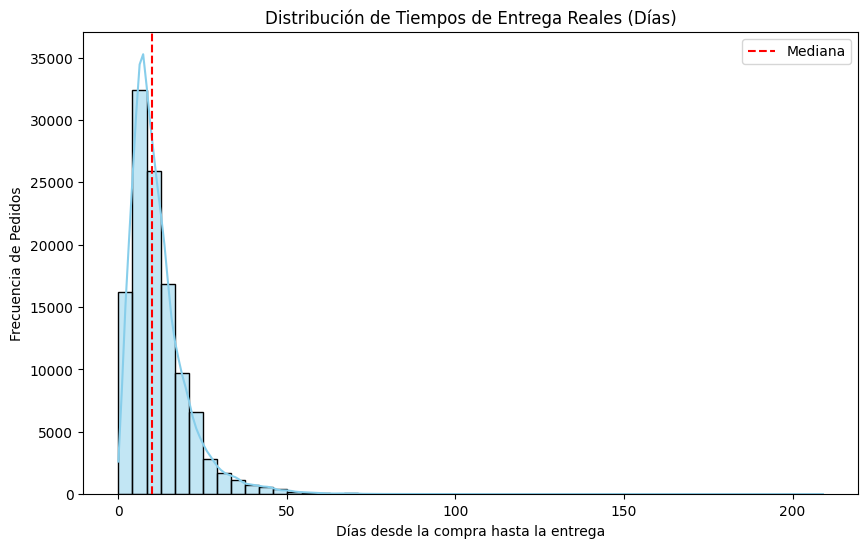

Mediana de entrega: 10.0 días
Promedio de entrega: 12.02 días


In [9]:
# Convertir columnas a formato fecha
df_delivery = df_olist.copy()
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    df_delivery[col] = pd.to_datetime(df_delivery[col])

# Calcular el tiempo real de entrega en días (Variable Objetivo)
df_delivery['actual_delivery_days'] = (df_delivery['order_delivered_customer_date'] - 
                                        df_delivery['order_purchase_timestamp']).dt.days

# Calcular el tiempo estimado por la plataforma (para comparar después)
df_delivery['estimated_delivery_days'] = (df_delivery['order_estimated_delivery_date'] - 
                                           df_delivery['order_purchase_timestamp']).dt.days

# Eliminar nulos (pedidos no entregados aún)
df_delivery = df_delivery.dropna(subset=['actual_delivery_days'])

# Visualizar la distribución de los días de entrega reales
plt.figure(figsize=(10, 6))
sns.histplot(df_delivery['actual_delivery_days'], bins=50, kde=True, color='skyblue')
plt.title('Distribución de Tiempos de Entrega Reales (Días)')
plt.xlabel('Días desde la compra hasta la entrega')
plt.ylabel('Frecuencia de Pedidos')
plt.axvline(df_delivery['actual_delivery_days'].median(), color='red', linestyle='--', label='Mediana')
plt.legend()
plt.show()

print(f"Mediana de entrega: {df_delivery['actual_delivery_days'].median()} días")
print(f"Promedio de entrega: {df_delivery['actual_delivery_days'].mean():.2f} días")
